# Code-Capacity Edge-Weight Heat Maps For Half-Stabilizer Errors

This notebook sweeps explicit edge-message weights on deterministic half-stabilizer `X` errors. The usual cells use no memory effect and no damping; the final cell adds weak memory and damping with all other parameters unchanged.


In [4]:
import importlib
from math import comb
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from relay_bp.analysis.code_capacity_common import default_export_code_paths

CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}
for fallback_key, fallback_path in default_export_code_paths(REPO_ROOT).items():
    if fallback_key not in CODE_PATHS or not CODE_PATHS[fallback_key].exists():
        CODE_PATHS[fallback_key] = fallback_path

available_code_keys = [key for key, path in CODE_PATHS.items() if Path(path).exists()]
if not available_code_keys:
    raise FileNotFoundError("No code paths are available. Update CODE_PATHS for this machine.")

selected_code = "gross"  # change here
if selected_code not in CODE_PATHS or not Path(CODE_PATHS[selected_code]).exists():
    selected_code = available_code_keys[0]
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.10
max_iter = 40
alpha = 1.0
center_values = np.linspace(0.80, 1.30, 6)
width_values = np.linspace(1.00, 3.00, 11)
random_draws_per_point = 2
n_error_samples = 300
base_seed = 0

show_progress = True
show_inner_case_progress = False
selected_row_weights = None
case_limit = None
sample_limit = None

weak_memory_interval = (-0.10, 0.10)
weak_damping_interval = (0.85, 0.95)

assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert np.all(width_values >= 0.0), "width_values must be non-negative."

edge_weight_application_scope = "stabilizer_support"  # options: "stabilizer_support", "all_edges"


In [ ]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root(Path.cwd()))
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import relay_bp
import relay_bp.analysis.code_capacity_common as code_capacity_common_module
import relay_bp.analysis.code_capacity_edge_weights as code_capacity_edge_weights_module

importlib.reload(code_capacity_common_module)
importlib.reload(code_capacity_edge_weights_module)

from relay_bp.analysis.code_capacity_common import (
    default_export_code_paths,
    decode_with_edge_message_weights,
    decode_with_memory_strengths,
    enumerate_half_stabilizer_cases,
    evaluate_decode_result,
    load_code_capacity_problem,
    make_min_sum_tracer,
    sample_random_error_cases,
)
from relay_bp.analysis.code_capacity_edge_weights import (
    best_edge_weight_rows,
    build_memory_strengths,
    edge_weight_heatmap_rows,
    evaluate_edge_weight_heatmap,
    interval_from_center_width,
)

CODE_PATHS = globals().get("CODE_PATHS", {})
for fallback_key, fallback_path in default_export_code_paths(REPO_ROOT).items():
    if fallback_key not in CODE_PATHS or not Path(CODE_PATHS[fallback_key]).exists():
        CODE_PATHS[fallback_key] = fallback_path
selected_code = globals().get("selected_code", "gross")
if selected_code not in CODE_PATHS or not Path(CODE_PATHS[selected_code]).exists():
    selected_code = next(key for key, path in CODE_PATHS.items() if Path(path).exists())
npz_path = Path(globals().get("npz_path", CODE_PATHS[selected_code]))

prior_error_rate = float(globals().get("prior_error_rate", 0.10))
max_iter = int(globals().get("max_iter", 40))
alpha = float(globals().get("alpha", 1.0))
center_values = np.asarray(globals().get("center_values", np.linspace(0.00, 1.00, 11)), dtype=np.float64)
width_values = np.asarray(globals().get("width_values", np.linspace(0.00, 2.00, 11)), dtype=np.float64)
random_draws_per_point = int(globals().get("random_draws_per_point", 2))
n_error_samples = int(globals().get("n_error_samples", 300))
base_seed = int(globals().get("base_seed", 0))
show_progress = bool(globals().get("show_progress", False))
show_inner_case_progress = bool(globals().get("show_inner_case_progress", False))
selected_row_weights = globals().get("selected_row_weights", None)
case_limit = globals().get("case_limit", None)
sample_limit = globals().get("sample_limit", None)
weak_memory_interval = tuple(globals().get("weak_memory_interval", (0.15, 0.15)))
weak_damping_interval = tuple(globals().get("weak_damping_interval", (0.85, 0.95)))


def load_css_code(path: Path) -> dict[str, object]:
    problem = load_code_capacity_problem(path, default_prior_error_rate=prior_error_rate)
    return {"problem": problem, "hx": problem.hx, "hz": problem.hz, "lz": problem.lz, "metadata": problem.metadata}


def dynamic_limits(values: np.ndarray) -> tuple[float, float]:
    finite = np.asarray(values, dtype=np.float64)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return (0.0, 1.0)
    vmin = float(finite.min())
    vmax = float(finite.max())
    if np.isclose(vmin, vmax):
        eps = 1e-6 if np.isclose(vmin, 0.0) else max(1e-6, abs(vmin) * 0.05)
        return (vmin - eps, vmax + eps)
    return (vmin, vmax)


def plot_heatmaps(artifact: dict[str, object], *, title: str):
    metrics = [
        ("logical_success_rate", "Logical success rate"),
        ("convergence_rate", "Convergence rate"),
        ("exact_recovery_rate", "Exact recovery rate"),
        ("mean_iterations", "Mean iterations"),
    ]
    centers = np.asarray(artifact["centers"], dtype=np.float64)
    widths = np.asarray(artifact["widths"], dtype=np.float64)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for axis, (metric_key, label) in zip(axes.flat, metrics):
        values = np.asarray(artifact[metric_key], dtype=np.float64)
        vmin, vmax = dynamic_limits(values)
        image = axis.imshow(
            values,
            origin="lower",
            aspect="auto",
            extent=[float(centers.min()), float(centers.max()), float(widths.min()), float(widths.max())],
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        axis.set_title(label)
        axis.set_xlabel("interval center")
        axis.set_ylabel("interval width")
        fig.colorbar(image, ax=axis, shrink=0.85)
    fig.suptitle(title, fontsize=14)
    return fig


def edge_grid_table(artifact: dict[str, object]) -> pd.DataFrame:
    return pd.DataFrame(edge_weight_heatmap_rows(artifact)).sort_values(
        ["logical_success_rate", "convergence_rate", "exact_recovery_rate", "mean_iterations", "width", "center"],
        ascending=[False, False, False, True, True, True],
    ).reset_index(drop=True)


def edge_best_points_table(artifact: dict[str, object], top_k: int = 8) -> pd.DataFrame:
    return pd.DataFrame(best_edge_weight_rows(edge_weight_heatmap_rows(artifact), topk=top_k)).reset_index(drop=True)


code_data = load_css_code(npz_path)
hz_check_matrix = code_data["hz"]
lz_matrix = code_data["lz"]

def stabilizer_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)
    rows = []
    total_even_weight_stabilizers = 0
    total_half_flip_patterns = 0
    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_half = count * half_subsets_per_row
        if is_even:
            total_even_weight_stabilizers += count
            total_half_flip_patterns += total_half
        rows.append(
            {
                "row_weight": weight,
                "n_x_stabilizers": count,
                "is_even_weight": is_even,
                "half_flip_patterns_per_row": half_subsets_per_row,
                "total_half_flip_patterns": total_half,
            }
        )
    summary = pd.DataFrame(
        [
            {
                "code": selected_code,
                "Hx_rows": int(hx.shape[0]),
                "n_qubits": int(hx.shape[1]),
                "even_weight_x_stabilizers": total_even_weight_stabilizers,
                "total_half_flip_patterns": total_half_flip_patterns,
                "random_draws_per_point": random_draws_per_point,
                "n_center_values": len(center_values),
                "n_width_values": len(width_values),
            }
        ]
    )
    return pd.DataFrame(rows), summary


def case_manifest(cases: list[dict[str, object]], head: int | None = 20) -> pd.DataFrame:
    manifest = pd.DataFrame(
        [
            {
                "case_id": int(case["case_id"]),
                "row_idx": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "half_subset_idx": int(case["half_subset_idx"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "support_bits": list(case["support_bits"]),
                "flipped_bits": list(case["flipped_bits"]),
            }
            for case in cases
        ]
    )
    return manifest.head(head) if head is not None else manifest


stabilizer_rows, stabilizer_summary = stabilizer_statistics(code_data["hx"])
all_cases = enumerate_half_stabilizer_cases(
    code_data["problem"],
    selected_row_weights=None if selected_row_weights is None else set(int(weight) for weight in selected_row_weights),
    max_cases=case_limit,
)
case_manifest_df = case_manifest(all_cases)

_smoke_problem = load_code_capacity_problem(default_export_code_paths(REPO_ROOT)["surface13"])
_smoke_tracer = relay_bp.MinSumBPDecoderTraceF64(
    _smoke_problem.hz,
    error_priors=_smoke_problem.error_priors,
    max_iter=6,
    alpha=1.0,
)
if hasattr(_smoke_tracer, "set_explicit_edge_message_weights"):
    _smoke_cases = enumerate_half_stabilizer_cases(_smoke_problem, max_cases=4)
    _smoke_artifact = evaluate_edge_weight_heatmap(
        problem=_smoke_problem,
        cases=_smoke_cases,
        max_iter=6,
        alpha=1.0,
        centers=[0.2],
        widths=[0.4],
        base_seed=3,
        random_draws_per_point=1,
        support_only=True,
    )
    assert _smoke_artifact["logical_success_rate"].shape == (1, 1)
    assert int(_smoke_artifact["trial_count"][0, 0]) == len(_smoke_cases)
else:
    print("Skipping edge-weight smoke decode because the local relay_bp extension is stale.")


## Half-Stabilizer Catalogue


In [11]:
display(stabilizer_summary)
display(stabilizer_rows)
display(case_manifest_df)


,code,Hx_rows,n_qubits,even_weight_x_stabilizers,total_half_flip_patterns,random_draws_per_point,n_center_values,n_width_values
0,gross,72,144,72,1440,2,6,11


,row_weight,n_x_stabilizers,is_even_weight,half_flip_patterns_per_row,total_half_flip_patterns
0,6,72,True,20,1440


,case_id,row_idx,row_weight,half_subset_idx,syndrome_weight,support_bits,flipped_bits
0,0,0,6,0,9,"[1, 2, 18, 75, 78, 84]","[1, 2, 18]"
1,1,0,6,1,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 75]"
2,2,0,6,2,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 78]"
3,3,0,6,3,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 84]"
4,4,0,6,4,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 75]"
5,5,0,6,5,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 78]"
6,6,0,6,6,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 84]"
7,7,0,6,7,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 78]"
8,8,0,6,8,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 84]"
9,9,0,6,9,5,"[1, 2, 18, 75, 78, 84]","[1, 78, 84]"


## Edge-Weight Heat Maps


edge-weight grid: 100%|██████████| 66/66 [01:20<00:00,  1.22s/it, center=1.300, conv=0.723, logical=0.764, width=3.000]


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,1.0,1.8,0.1,1.9,0.861458,0.815625,0.410764,15.323958,2880
1,0.9,1.4,0.2,1.6,0.852778,0.778819,0.394097,17.009722,2880
2,1.0,2.0,0.0,2.0,0.846528,0.790972,0.417361,15.460069,2880
3,0.9,1.6,0.1,1.7,0.834375,0.766667,0.387847,16.738542,2880
4,0.9,1.0,0.4,1.4,0.834028,0.730208,0.369792,19.938194,2880
5,1.0,1.4,0.3,1.7,0.831597,0.777778,0.384722,17.788194,2880
6,1.0,1.6,0.2,1.8,0.830556,0.776042,0.373264,16.949306,2880
7,1.0,1.2,0.4,1.6,0.830208,0.778472,0.397569,18.121528,2880


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,1.0,1.8,0.1,1.9,0.861458,0.815625,0.410764,15.323958,2880
1,0.9,1.4,0.2,1.6,0.852778,0.778819,0.394097,17.009722,2880
2,1.0,2.0,0.0,2.0,0.846528,0.790972,0.417361,15.460069,2880
3,0.9,1.6,0.1,1.7,0.834375,0.766667,0.387847,16.738542,2880
4,0.9,1.0,0.4,1.4,0.834028,0.730208,0.369792,19.938194,2880
5,1.0,1.4,0.3,1.7,0.831597,0.777778,0.384722,17.788194,2880
6,1.0,1.6,0.2,1.8,0.830556,0.776042,0.373264,16.949306,2880
7,1.0,1.2,0.4,1.6,0.830208,0.778472,0.397569,18.121528,2880
8,1.0,1.0,0.5,1.5,0.829861,0.769097,0.388889,18.721875,2880
9,1.1,2.0,0.1,2.1,0.827083,0.787500,0.402431,16.393403,2880


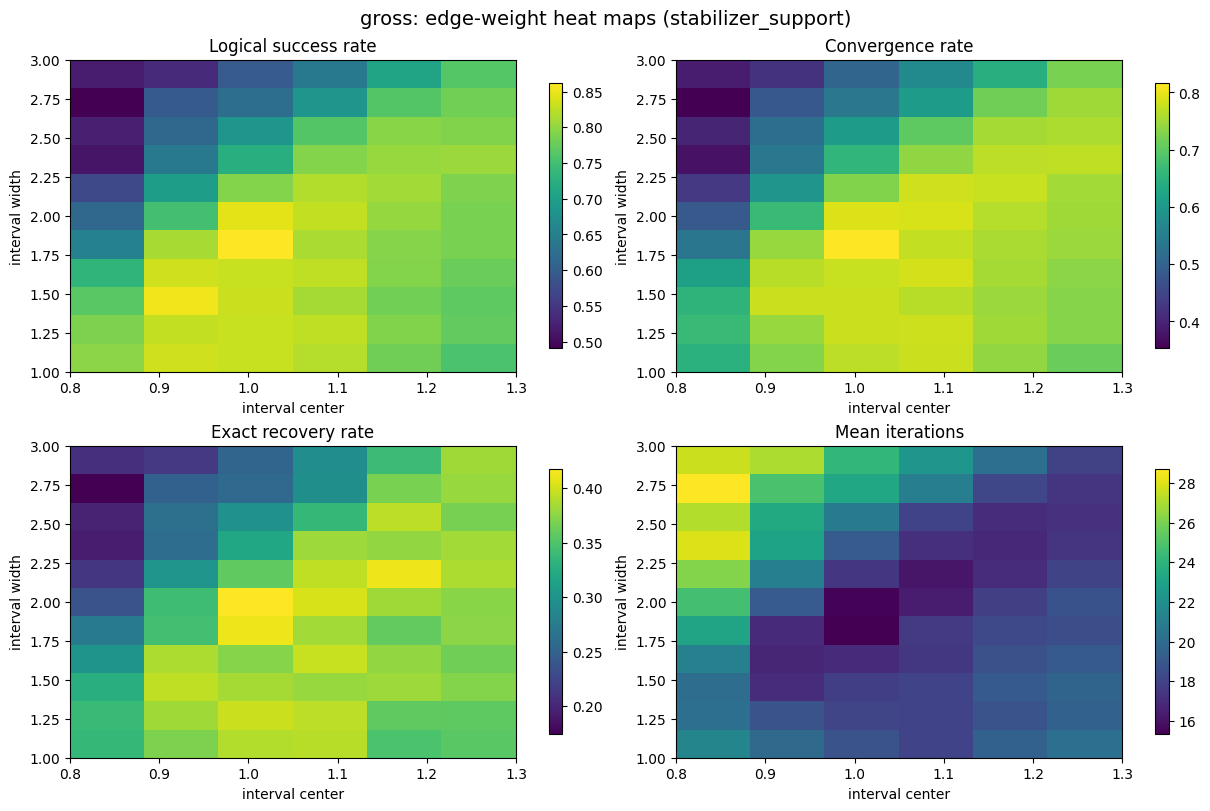

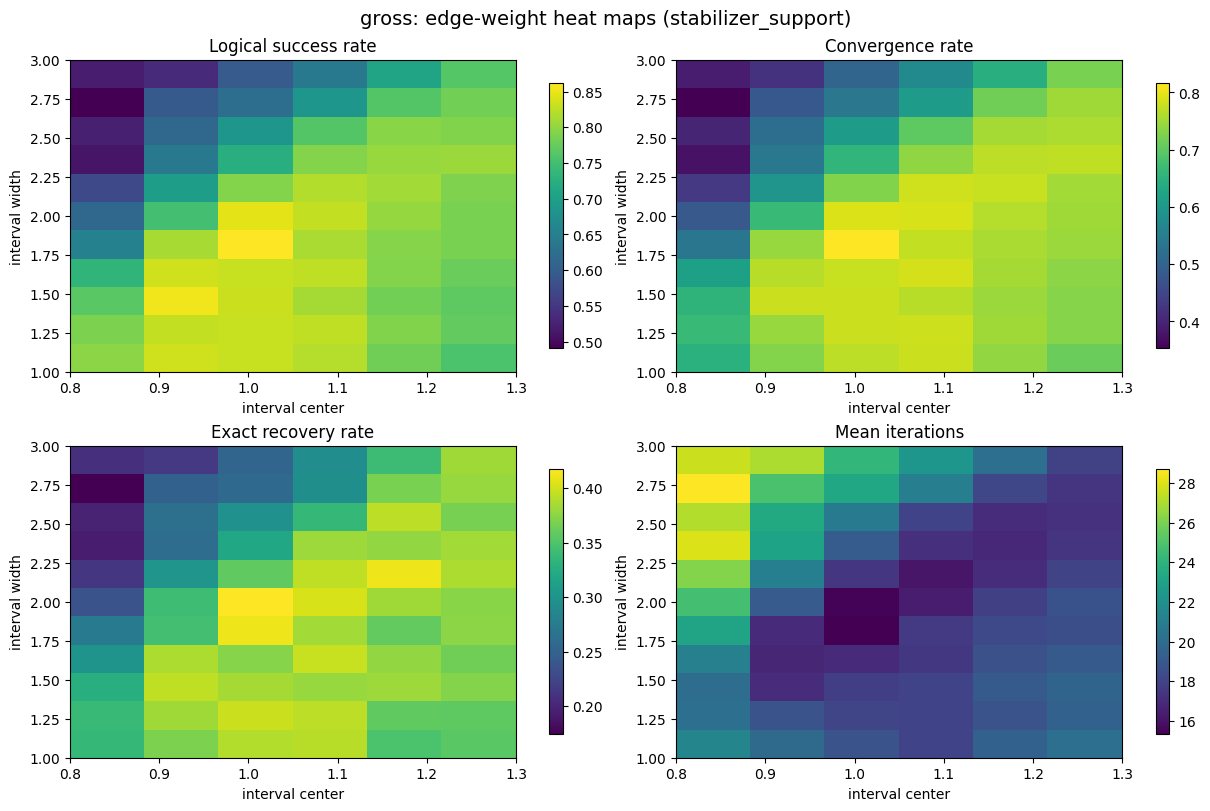

In [12]:
artifact = evaluate_edge_weight_heatmap(
    problem=code_data["problem"],
    cases=all_cases,
    max_iter=max_iter,
    alpha=alpha,
    centers=center_values.tolist(),
    widths=width_values.tolist(),
    base_seed=base_seed,
    random_draws_per_point=random_draws_per_point,
    support_only=edge_weight_application_scope == "stabilizer_support",
    show_progress=show_progress,
    show_inner_case_progress=show_inner_case_progress,
)
heatmap_df = edge_grid_table(artifact)
best_points_df = edge_best_points_table(artifact)

display(best_points_df)
display(heatmap_df.head(16))
fig = plot_heatmaps(artifact, title=f"{selected_code}: edge-weight heat maps ({edge_weight_application_scope})")
fig


## Weak Memory + Damping Extension


edge-weight grid: 100%|██████████| 66/66 [01:57<00:00,  1.78s/it, center=1.300, conv=0.829, logical=0.856, width=3.000]


,weak_memory_low,weak_memory_high,weak_damping_low,weak_damping_high
0,-0.1,0.1,0.85,0.95


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.9,1.0,0.4,1.4,0.981250,0.971181,0.488889,8.012153,2880
1,1.0,1.0,0.5,1.5,0.974653,0.967708,0.505903,9.483333,2880
2,0.9,1.2,0.3,1.5,0.969792,0.959028,0.488194,7.998958,2880
3,1.0,1.4,0.3,1.7,0.969097,0.957639,0.484028,8.621181,2880
4,1.0,1.2,0.4,1.6,0.968403,0.956944,0.473958,9.044097,2880
5,0.9,1.4,0.2,1.6,0.962500,0.943403,0.492361,8.085069,2880
6,1.1,1.6,0.3,1.9,0.961458,0.952778,0.477083,9.334722,2880
7,1.0,1.6,0.2,1.8,0.961458,0.952431,0.480556,8.439236,2880


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.9,1.0,0.4,1.4,0.981250,0.971181,0.488889,8.012153,2880
1,1.0,1.0,0.5,1.5,0.974653,0.967708,0.505903,9.483333,2880
2,0.9,1.2,0.3,1.5,0.969792,0.959028,0.488194,7.998958,2880
3,1.0,1.4,0.3,1.7,0.969097,0.957639,0.484028,8.621181,2880
4,1.0,1.2,0.4,1.6,0.968403,0.956944,0.473958,9.044097,2880
5,0.9,1.4,0.2,1.6,0.962500,0.943403,0.492361,8.085069,2880
6,1.1,1.6,0.3,1.9,0.961458,0.952778,0.477083,9.334722,2880
7,1.0,1.6,0.2,1.8,0.961458,0.952431,0.480556,8.439236,2880
8,1.1,1.8,0.2,2.0,0.958681,0.949653,0.465972,9.211111,2880
9,1.1,1.4,0.4,1.8,0.954514,0.945139,0.476042,10.136458,2880


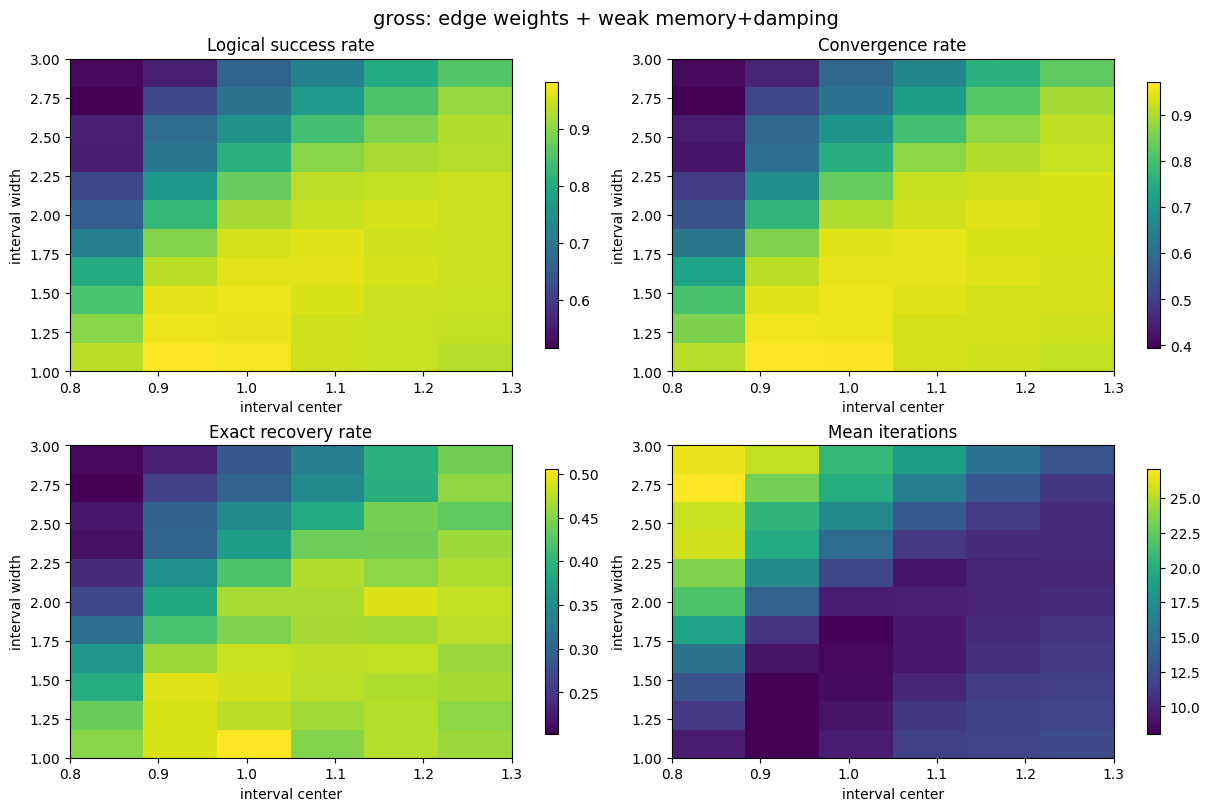

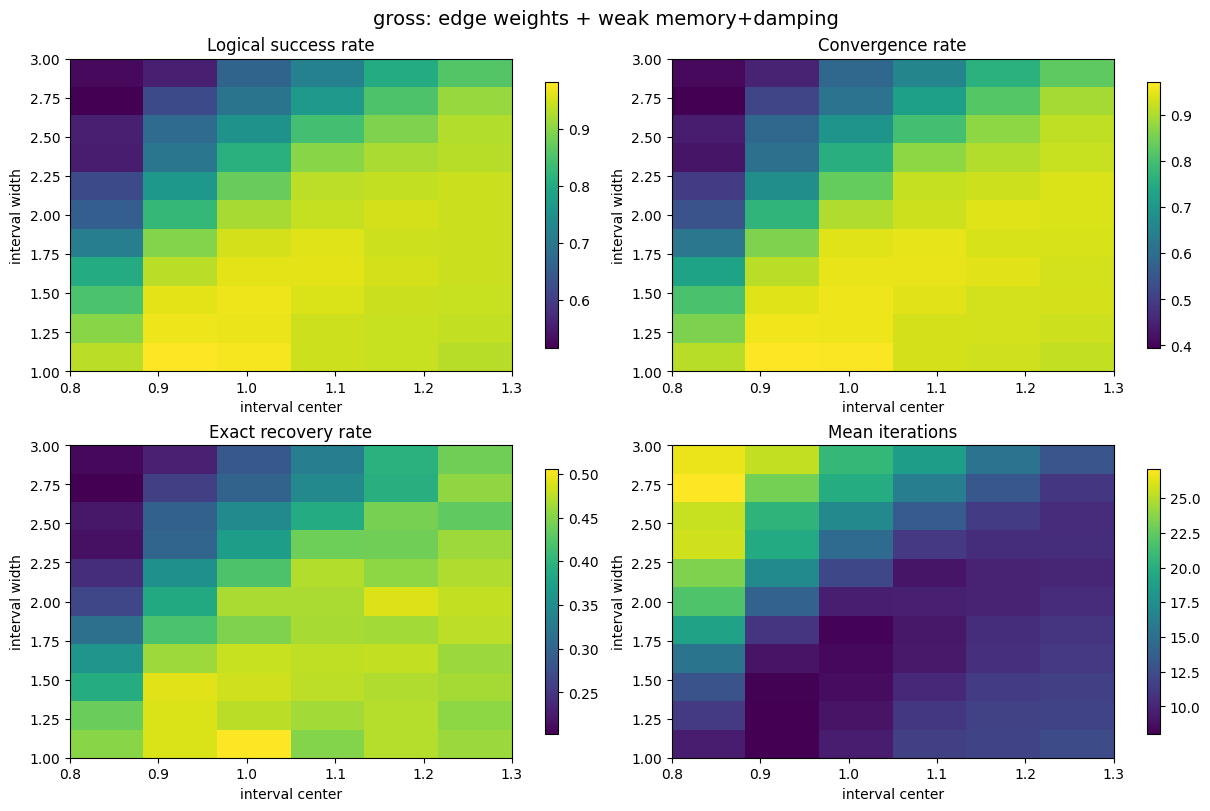

In [ ]:
weak_joint_artifact = evaluate_edge_weight_heatmap(
    problem=code_data["problem"],
    cases=all_cases,
    max_iter=max_iter,
    alpha=alpha,
    centers=center_values.tolist(),
    widths=width_values.tolist(),
    base_seed=base_seed,
    random_draws_per_point=random_draws_per_point,
    support_only=edge_weight_application_scope == "stabilizer_support",
    memory_interval=weak_memory_interval,
    damping_interval=weak_damping_interval,
    show_progress=show_progress,
    show_inner_case_progress=show_inner_case_progress,
)
weak_joint_heatmap_df = edge_grid_table(weak_joint_artifact)
weak_joint_best_points_df = edge_best_points_table(weak_joint_artifact)

display(pd.DataFrame([{
    "weak_memory_low": float(weak_memory_interval[0]),
    "weak_memory_high": float(weak_memory_interval[1]),
    "weak_damping_low": float(weak_damping_interval[0]),
    "weak_damping_high": float(weak_damping_interval[1]),
}]))
display(weak_joint_best_points_df)
display(weak_joint_heatmap_df.head(16))
weak_joint_fig = plot_heatmaps(weak_joint_artifact, title=f"{selected_code}: edge weights + weak memory+damping")
weak_joint_fig
